# Trajectory Inference with scTour

Here we use raw UMI counts from pancreas endocrine development to demonstrate latent-time learning and neural ordinary-differential-equation-based trajectory modeling with scTour.

## Method background

Following the [scTour documentation](https://sctour.readthedocs.io/) and the original [Genome Biology paper](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-023-02988-9), scTour is a deep-learning framework that jointly learns latent representations, developmental pseudotime, and vector fields from abundance matrices.

Its core logic is:

- encode cells into a latent space that captures developmental structure
- learn pseudotime without requiring spliced/unspliced counts
- fit a neural ODE-style dynamics model to describe continuous state transitions
- use the learned latent dynamics to support inference and prediction of cellular progression

This makes scTour especially attractive when we want a neural latent-time model and do not want to rely on RNA-velocity preprocessing.

## Why use the pancreas dataset here?

Pancreatic endocrine development provides a compact progression with clear intermediate endocrine states, which makes it easier to inspect whether scTour recovers a sensible latent-time ordering and developmental direction.

## Preprocess data

As an example, we apply trajectory inference to pancreas development.


In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata=ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔍 [2026-04-28 15:48:13] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']



✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.07s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.47 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.3018s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (55.64s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 55.64s                                                  │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells. In our experience, often a rough estimate of the number of PCs does fine.

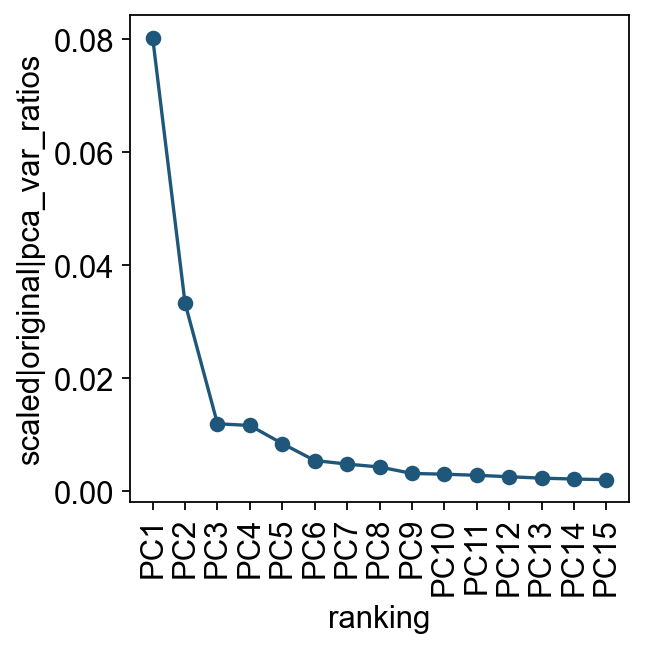

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


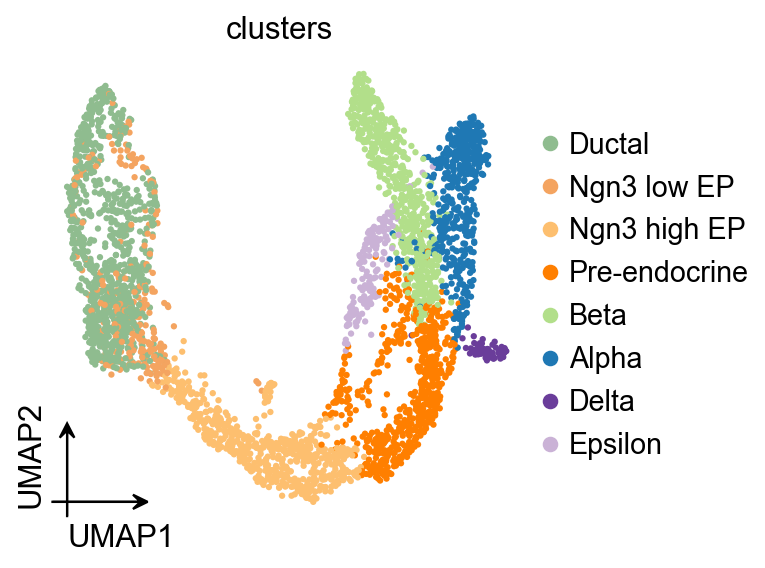

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## scTour

scTour is an innovative and comprehensive method for dissecting cellular dynamics by analysing datasets derived from single-cell genomics.

It provides a unifying framework to depict the full picture of developmental processes from multiple angles including the developmental pseudotime, vector field and latent space.

Now we are ready to train the scTour model. The default loss_mode is negative binomial conditioned likelihood (nb), which requires raw UMI counts (stored in .X of the AnnData) as input. By default, the percentage of cells used to train the model is set to 0.9 when the total number of cells is less than 10,000 and 0.2 when greater than 10,000. Users can adjust the percentage by using the parameter percent (for example percent=0.6).

In [6]:
adata.X=adata.layers['counts'].copy()
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

In [7]:
Traj=ov.single.TrajInfer(
    adata,basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50
)
Traj.inference(
    method='sctour',
    alpha_recon_lec=0.5,
    alpha_recon_lode=0.5
)

Running using CPU.


  0%|          | 0/400 [00:00<?, ?epoch/s]

Epoch 1:   0%|          | 0/400 [00:00<?, ?epoch/s]

Epoch 1:   0%|          | 1/400 [00:00<04:14,  1.57epoch/s, train_loss=2.29e+3, val_loss=2.22e+3]

Epoch 2:   0%|          | 1/400 [00:01<04:14,  1.57epoch/s, train_loss=2.29e+3, val_loss=2.22e+3]

...

Epoch 399: 100%|█████████▉| 398/400 [04:07<00:01,  1.51epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 399: 100%|█████████▉| 399/400 [04:07<00:00,  1.55epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 400: 100%|█████████▉| 399/400 [04:07<00:00,  1.55epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 400: 100%|██████████| 400/400 [04:07<00:00,  1.54epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

Epoch 400: 100%|██████████| 400/400 [04:07<00:00,  1.61epoch/s, train_loss=1.31e+3, val_loss=1.31e+3]

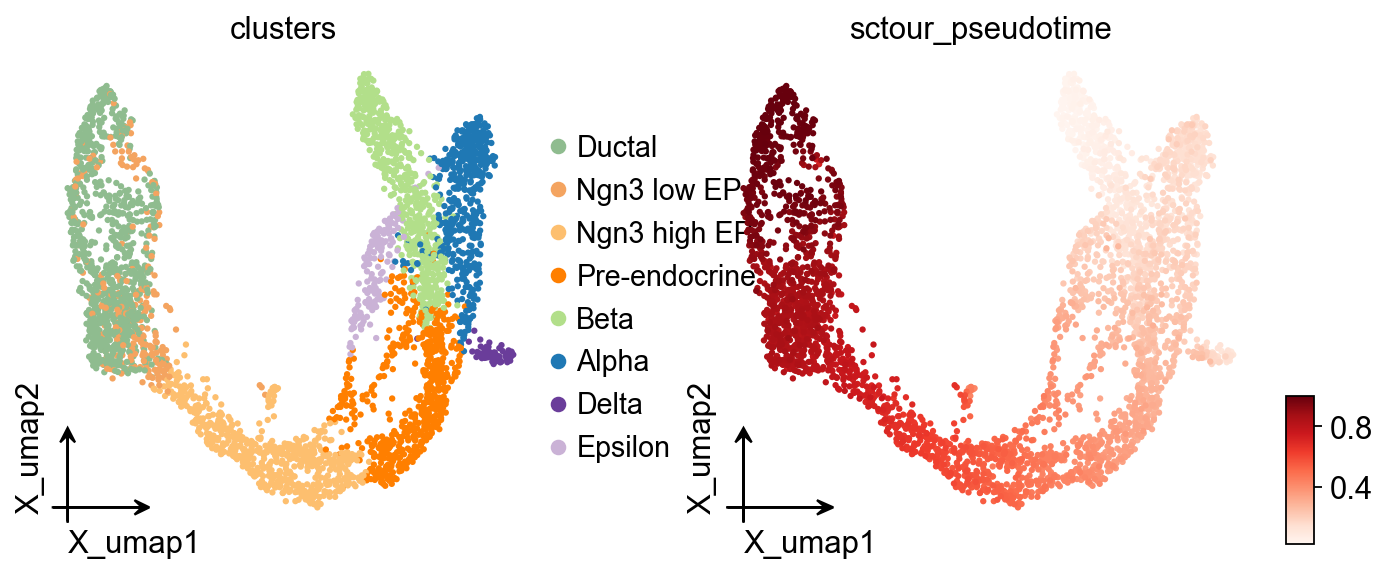

In [8]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color=['clusters','sctour_pseudotime'],
    frameon='small',
    cmap='Reds'
)

In [9]:
adata.obs['sctour_pseudotime']=1-adata.obs['sctour_pseudotime']

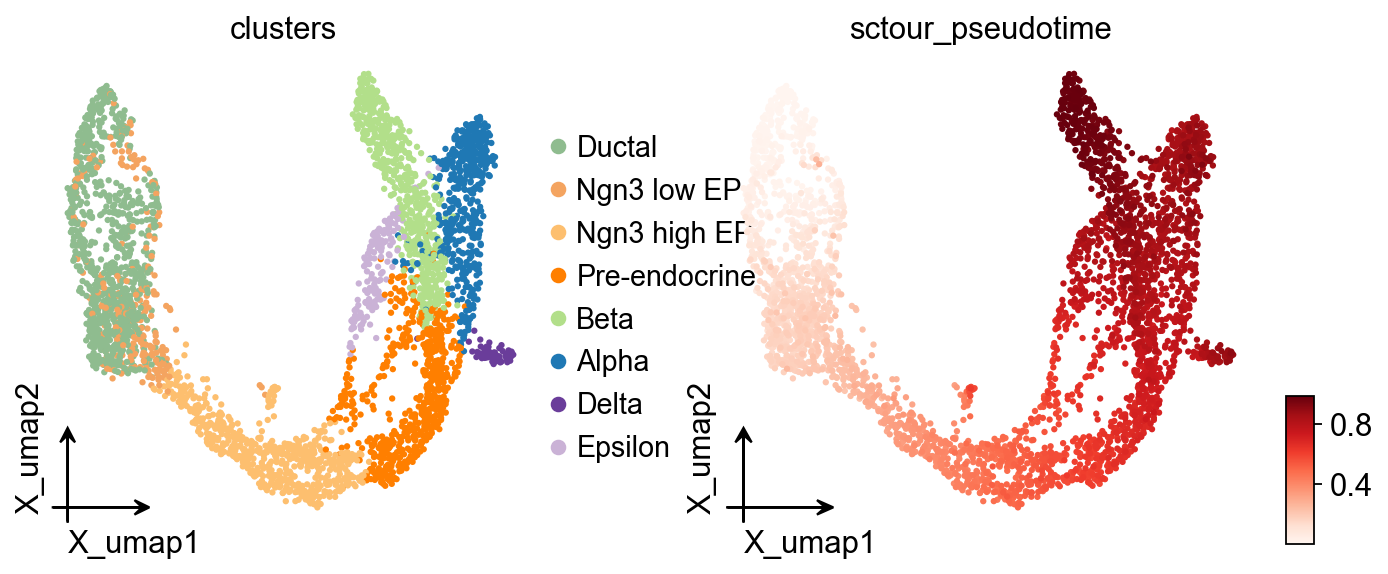

In [10]:
ov.pl.embedding(
    adata,basis='X_umap',
    color=['clusters','sctour_pseudotime'],
    frameon='small',
    cmap='Reds'
)

## OV trajectory graph overlay

scTour provides a learned pseudotime. We use it as a PAGA time prior and draw the result with the shared `ov.pl.trajectory` interface.

running PAGA using priors: ['sctour_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


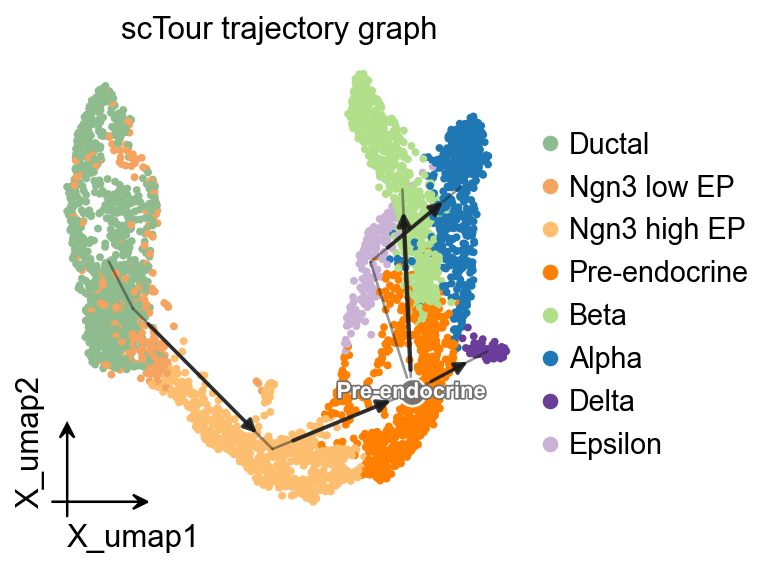

In [11]:
sc.pp.neighbors(adata, use_rep='X_pca')
ov.utils.cal_paga(
    adata,
    use_time_prior='sctour_pseudotime',
    vkey='paga',
    groups='clusters',
)
ov.pl.trajectory(
    adata,
    method='paga',
    basis='X_umap',
    groups='clusters',
    color='clusters',
    title='scTour trajectory graph',
)
plt.show()


## OV trajectory overlay

`ov.pl.trajectory_overlay` adds the PAGA backbone to an existing UMAP embedding.

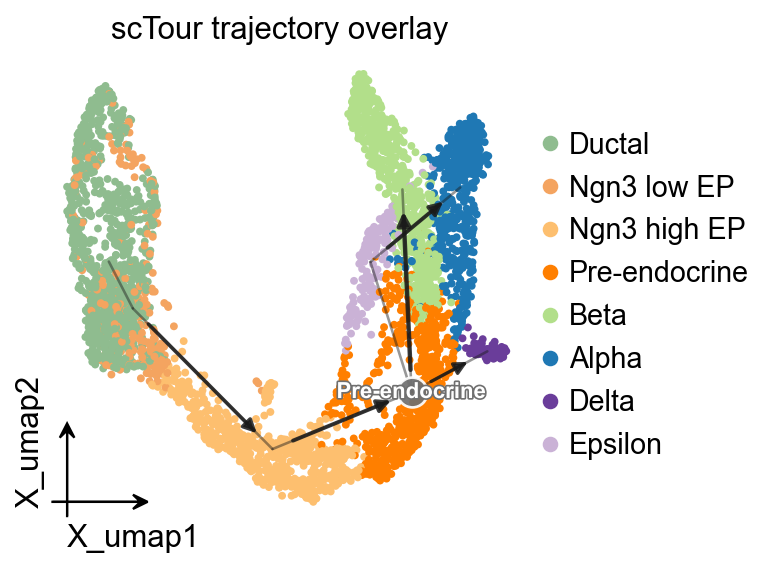

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='clusters',
    ax=ax,
    show=False,
    size=50,
)
ov.pl.trajectory_overlay(
    adata,
    ax=ax,
    method='paga',
    basis='X_umap',
    groups='clusters',
)
ax.set_title('scTour trajectory overlay')
plt.show()


In [13]:
import os

os.makedirs('data', exist_ok=True)
adata.write('data/traj_tutorial.h5ad')

In [14]:
adata=ov.read('data/traj_tutorial.h5ad')
adata

AnnData object with n_obs × n_vars = 3696 × 3000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'n_genes_by_counts', 'total_counts', 'sctour_pseudotime'
    var: 'highly_variable_genes', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'REFERENCE_MANU', '_ov_provenance', 'clusters_coarse_colors', 'clusters_colors', 'clusters_sizes', 'day_colors', 'history_log', 'hvg', 'log1p', 'neighbors', 'paga', 'paga_graph', 'pca', 'scaled|original|cum_sum_eigenvalues', 'scaled|original|pca_var_ratios', 'status', 'status_args'
    obsm: 'UMAP', 'X_TNODE', 'X_VF', 'X_pca', 'X_umap', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

## Branch-aware pseudotime stream plot

`ov.pl.branch_streamplot` uses only a pseudotime vector and cell-state labels, so it can summarize the branch structure inferred by this method as a compact river-style plot. The width of each ribbon shows where a cell state is enriched along pseudotime, while the split centerlines highlight terminal endocrine fates.



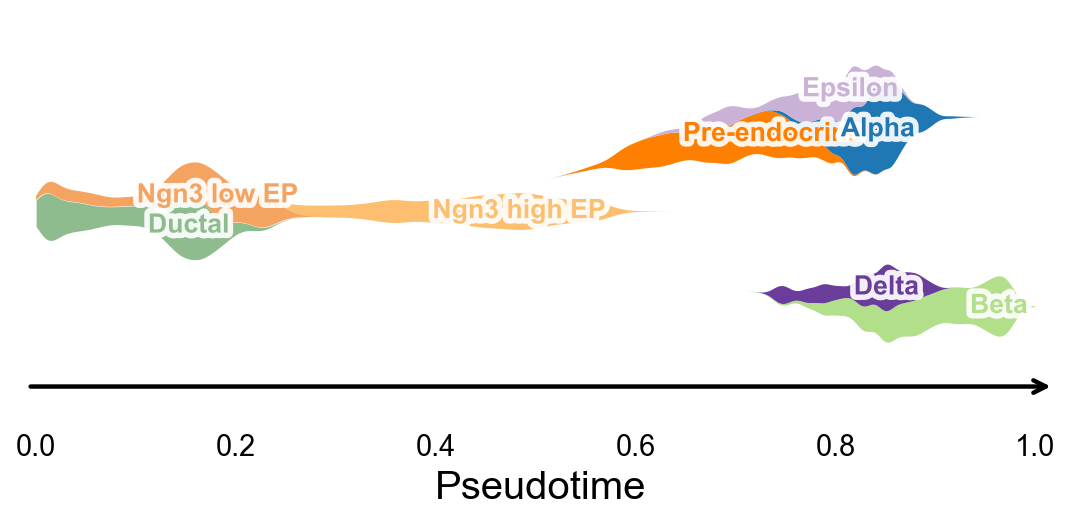

In [15]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='sctour_pseudotime',
    show=False,
)
plt.show()


## Fit `dynamic_features` / `dynamic_trends` with scTour pseudotime

The same marker-trend workflow can be applied to `sctour_pseudotime`. We first show a global marker panel with points colored by clusters, then compare late Alpha and Beta programs in a branch-aware view.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sctour_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

sctour_dyn = ov.single.dynamic_features(
    adata,
    genes=sctour_genes,
    pseudotime='sctour_pseudotime',
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)


🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: sctour_pseudotime
   Stored raw obs keys: ['clusters']
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


### Single-line global trends

This view fits one global curve per gene and colors the raw cells by annotation. It is useful for separating the overall pseudotime trend from the cell-state composition that appears around that trend.




🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False
✅ Dynamic trend plotting completed!


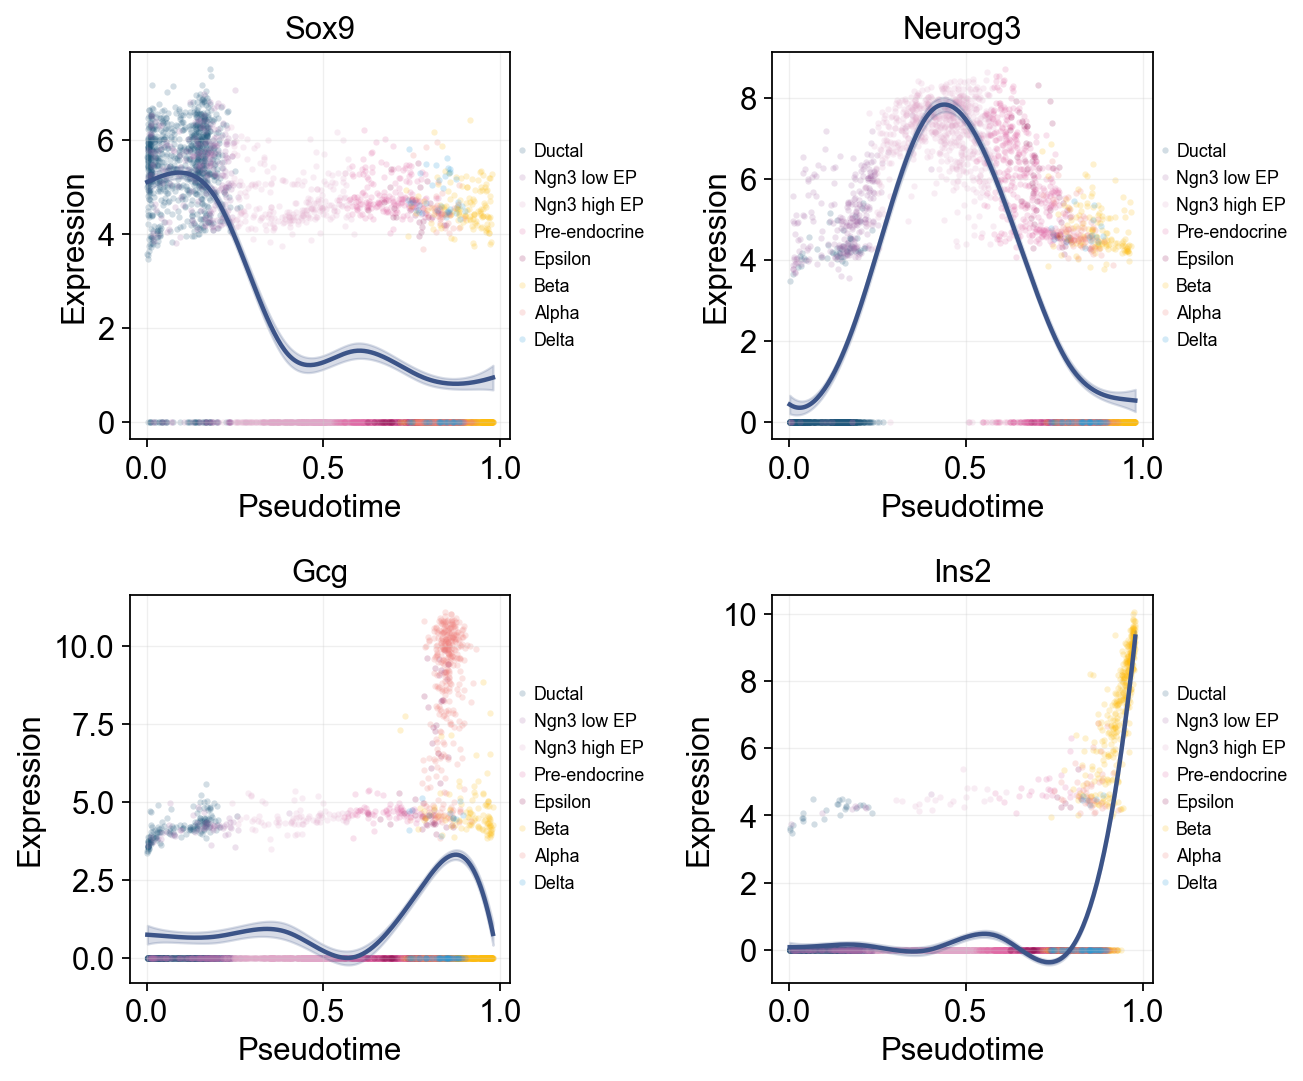

In [17]:
fig, _ = ov.pl.dynamic_trends(
    sctour_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
    ncols=2,
    return_fig=True,
)
display(fig)
plt.close(fig)


### Multi-marker trend comparison

Here multiple marker curves are overlaid so their activation timing can be compared directly along the same pseudotime axis.



🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False
✅ Dynamic trend plotting completed!


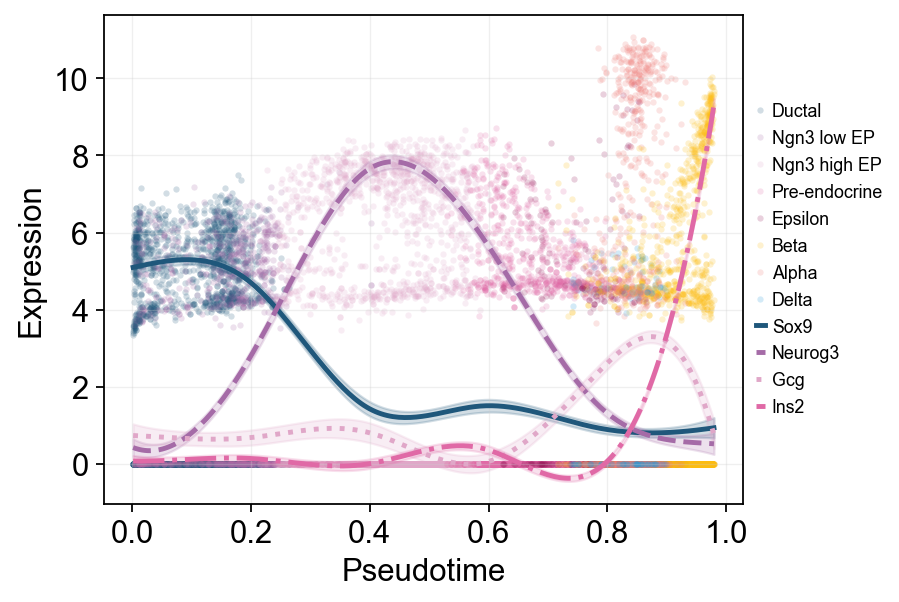

In [18]:
fig, _ = ov.pl.dynamic_trends(
    sctour_dyn,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    figsize=(7, 4),
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
    return_fig=True,
)
display(fig)
plt.close(fig)


In [19]:
branch_clusters = ['Alpha', 'Beta']
split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])

sctour_branch_dyn = ov.single.dynamic_features(
    adata,
    genes=['Gcg', 'Ins2', 'Pax4', 'Sox9'],
    pseudotime='sctour_pseudotime',
    groupby='clusters',
    groups=branch_clusters,
    use_raw=adata.raw is not None,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
split_time = float(np.nanmedian(adata.obs.loc[split_mask, 'sctour_pseudotime'])) if split_mask.any() else float(np.nanmedian(adata.obs['sctour_pseudotime']))



🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: sctour_pseudotime
   Grouping: clusters
   Expression source: adata.raw
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 4288



🔍 Dynamic trend plotting:
   Features: 3 | Groups: 2
   compare_features=False | compare_groups=True
✅ Dynamic trend plotting completed!


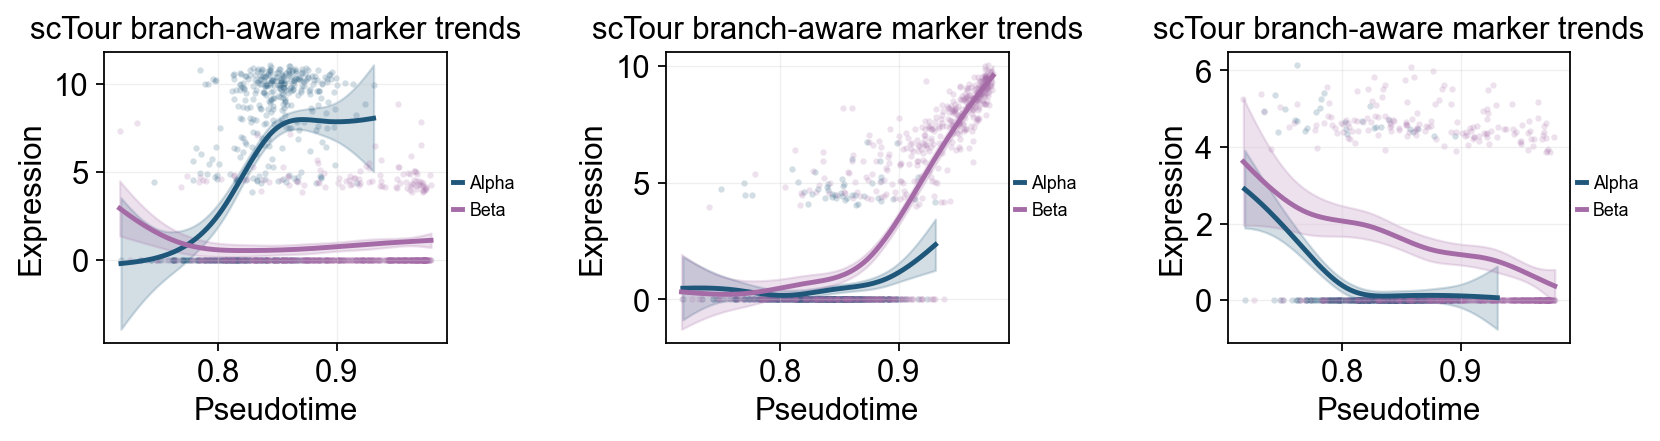

In [20]:
fig, _ = ov.pl.dynamic_trends(
    sctour_branch_dyn,
    genes=['Gcg', 'Ins2', 'Pax4'],
    compare_groups=True,
    split_time=split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(4.2, 3),
    ncols=3,
    linewidth=2.2,
    legend_loc='right margin',
    legend_fontsize=8,
    title='scTour branch-aware marker trends',
    return_fig=True,
)
display(fig)
plt.close(fig)


## Summarize scTour marker programs with `dynamic_heatmap`

`ov.pl.dynamic_heatmap` compresses several marker programs into one pseudotime-ordered panel. It is useful for checking whether progenitor, Alpha, Beta, and Delta programs activate in the expected order inferred by scTour.




🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: sctour_pseudotime
   Cell annotation: clusters
   use_fitted=True | cell_bins=180 | cmap=RdBu_r



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 180 columns


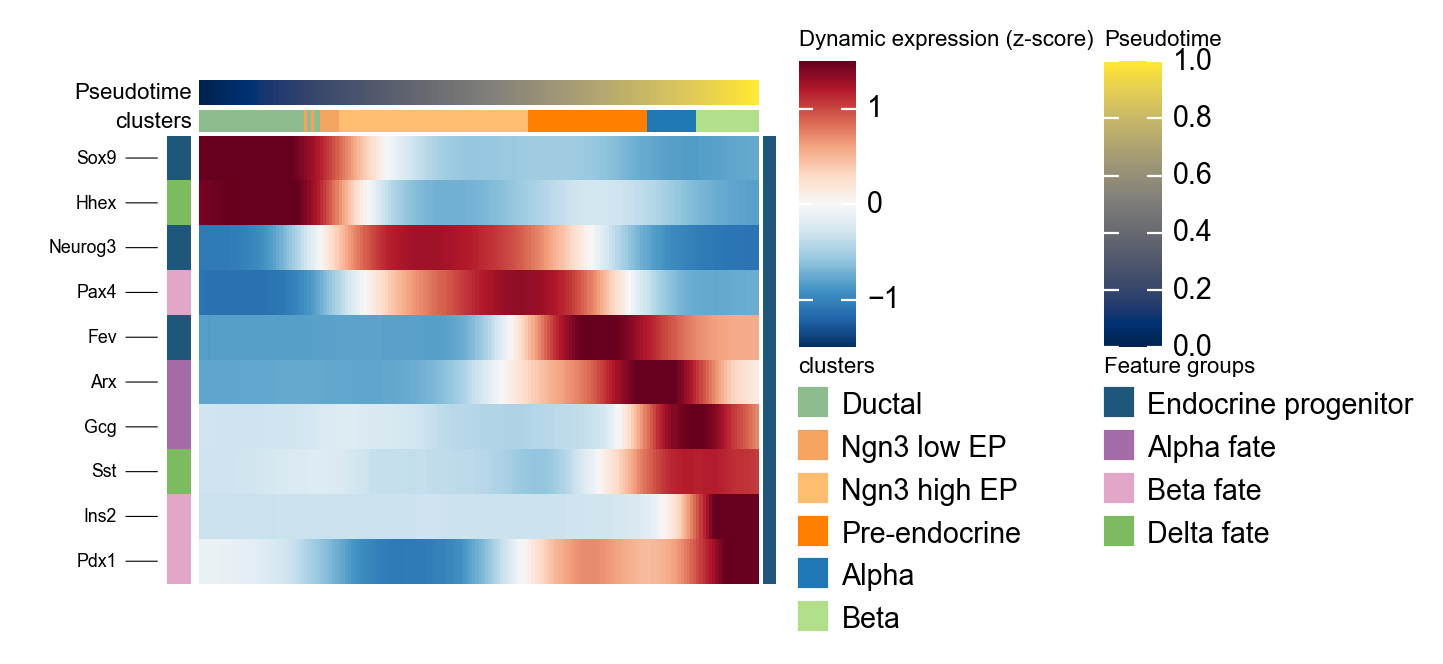

In [21]:
sctour_marker = {
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
}

g = ov.pl.dynamic_heatmap(
    adata,
    var_names=sctour_marker,
    pseudotime='sctour_pseudotime',
    use_raw=adata.raw is not None,
    use_cell_columns=False,
    cell_annotation='clusters',
    cell_bins=180,
    smooth_window=17,
    fitted_window=31,
    figsize=(5, 4),
    standard_scale='var',
    cmap='RdBu_r',
    use_fitted=True,
    border=False,
    show=False,
)